# Vision Transformer (ViT) Implementation for Flower Classification

**Paper:** " An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale"

**Authors:**  Dosovitskiy et al., Google Research, ICLR 2021

**Paper Link**:  https://arxiv.org/abs/2010.11929


# Overview

This notebook implements the Vision Transformer (ViT) architecture as described in the paper. The key insight from the paper is that pure transformer architectures, originally designed for NLP, can be applied directly to images with minimal modifications.

**Main Idea**: Split an image into fixed-size patches, linearly embed each patch, add position embeddings, and feed the sequence to a standard Transformer encoder.

## Architecture Summary (from paper)

**ViT-Base/16 configuration:**
- **Input**: Image of size 224×224×3
- **Patch Size**: 16×16 (resulting in 196 patches)
- **Embedding Dimension**: 768 (ViT-Base configuration)
- **Transformer Layers**: 12
- **MLP Size**: 3072 (4× embedding dimension)
- **Attention Heads**: 12

**Architecture Pipeline** (Figure 1 from paper):
```
Image (224×224×3) 
    ↓
Patch Embedding (196 patches of 16×16)
    ↓
Linear Projection (196×768)
    ↓
Add [CLS] token + Position Embedding (197×768)
    ↓
Transformer Encoder ×12
    ↓
MLP Head (classification)
    ↓
Class Predictions
```

# Setup: Import Libraries

First, we bring in all the tools we need for working with images and building our model.

In [1]:
# import Libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import torch
import torchvision 
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# Check if we can use GPU (faster) or CPU:

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device 

'cuda'

# Loading Our Data

We have three folders of flower images: one for training, one for validation, and one for testing.

In [3]:
train_dir = "/kaggle/input/flowers-dataset/train"
val_dir   = "/kaggle/input/flowers-dataset/valid"
test_dir  = "/kaggle/input/flowers-dataset/test"

## Creating Data Loaders

This function loads our images in batches and prepares them for training:


In [4]:
NUM_WORKERS = os.cpu_count()

def create_dataloader(train_dir:str, val_dir:str, test_dir:str, transform:transforms.Compose, batch_size:int, num_workers:int=NUM_WORKERS):
    train_data = datasets.ImageFolder(train_dir, transform=transform)
    val_data   = datasets.ImageFolder(val_dir, transform=transform)
    test_data  = datasets.ImageFolder(test_dir, transform=transform)

    class_names = train_data.classes

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False,  num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader, class_names

## Preparing Images

All images need to be the same size (224x224 pixels) and converted to numbers the model can understand:


In [5]:
IMG_SIZE = 224

manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print(f"Manual creayed transform: {manual_transforms}")

Manual creayed transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


Load our data with 32 images per batch:

In [6]:
# Setup dataloaders
BATCH_SIZE = 32

train_dataloader, val_dataloader, test_dataloader, class_names = create_dataloader(
    train_dir=train_dir,
    val_dir=val_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)

train_dataloader,val_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7c057552d8b0>,
 ['daisy', 'dandelion'])

# Visualizing a Sample Image

Let's look at one image to make sure everything is working:

torch.Size([3, 224, 224]) tensor(1)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

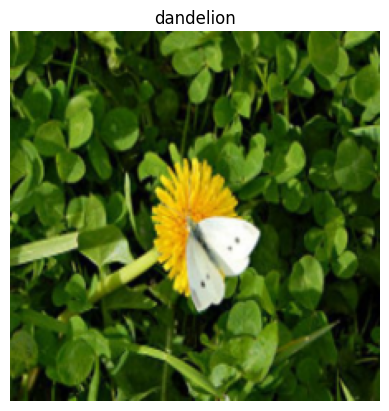

In [7]:
image_batch, labels_batch = next(iter(train_dataloader))

image, label = image_batch[0], labels_batch[0]

print(image.shape, label)

plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis(False)

# Building the Vision Transformer

## Step 1: Patch Embedding (Section 3.1 from paper)

**From the paper**: "We split an image into fixed-size patches, flatten the patches and map to D dimensions with a trainable linear projection."

The original image is divided into non-overlapping patches of size 16×16. Each patch is then flattened and linearly projected to the embedding dimension.

**Mathematical notation from paper**:
- Input image: **x** ∈ ℝ^(H×W×C)
- Patch size: P = 16
- Number of patches: N = HW/P² = 224×224/16² = 196
- Flattened patches: **x_p** ∈ ℝ^(N×(P²·C))
- Embedding: **E** ∈ ℝ^((P²·C)×D)

In [8]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels:int=3, patch_size:int=16, embedding_dim:int=768):
        super().__init__()
         # Linear projection of flattened patches (implemented as Conv2d)
        self.patcher = nn.Conv2d(
            in_channels=in_channels,
            out_channels = embedding_dim,
            kernel_size = patch_size,
            stride = patch_size,
            padding = 0
        )

        self.flatten = nn.Flatten(
            start_dim=2,
            end_dim=3
        )

    def forward(self, x):
        image_resolution = x.shape[-1]
        assert image_resolution%patch_size == 0, f"Input size must be divisible by  patch size, image size: {image_resolution}"

        x_patched = self.patcher(x)
        x_flattened = self.flatten(x_patched)
        x = x_flattened.permute(0,2,1)
        return x

In [9]:
patch_size = 16

def set_seeds(seed:int=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

set_seeds()

patch_layer = PatchEmbedding(in_channels=3, patch_size=16, embedding_dim=768)

print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patch_layer(image.unsqueeze(0))
print(f"Output patch embedding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768])


In [10]:
print(patch_embedded_image)
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[-0.2355,  0.1200, -0.1777,  ...,  0.1935, -0.0947,  0.1103],
         [-0.0524,  0.0379, -0.0803,  ...,  0.1015, -0.0589,  0.0461],
         [-0.0474,  0.0354, -0.0204,  ...,  0.0706, -0.0984,  0.0244],
         ...,
         [-0.1239,  0.0411, -0.1034,  ...,  0.0992, -0.0496,  0.0768],
         [-0.2823,  0.0246, -0.1077,  ...,  0.2967, -0.0330, -0.1285],
         [-0.1289,  0.0738, -0.0823,  ...,  0.1136, -0.0584,  0.0279]]],
       grad_fn=<PermuteBackward0>)
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


## Step 2: Class Token and Position Embeddings (Section 3.1 from paper)

**From the paper**: "Similar to BERT's [class] token, we prepend a learnable embedding to the sequence of embedded patches (z⁰₀ = x_class), whose state at the output of the Transformer encoder (z⁰_L) serves as the image representation y."

**Position embeddings**: "Position embeddings are added to the patch embeddings to retain positional information. We use standard learnable 1D position embeddings."

The paper uses:
- **Class token**: A learnable embedding prepended to the sequence
- **Position embeddings**: Learnable 1D embeddings added to patch embeddings

**Equation from paper**:
```
z₀ = [x_class; x¹_pE; x²_pE; ...; xᴺ_pE] + E_pos
```

Where:
- z₀ is the input to the Transformer encoder
- x_class is the class token
- E is the patch embedding projection
- E_pos are the position embeddings

In [11]:
set_seeds()

patch_size = 16

print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

patch_embedding_layer = PatchEmbedding(in_channels=3, patch_size=16, embedding_dim=768)
patch_embedding = patch_embedding_layer(x)
print(f"Patch embedding shape:{patch_embedding.shape}")

# Class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.rand(batch_size, 1, embedding_dimension), requires_grad=True)
print(f"class token shape: {class_token.shape}")

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"patch embedding with class token shape: {patch_embedding_class_token.shape}")

# Positional embeddding
number_of_patches = int((height * width)/patch_size**2)
position_embedding = nn.Parameter(torch.rand(1, number_of_patches+1, embedding_dimension), requires_grad=True)

patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embeddding shape: {patch_and_position_embedding.shape}")

print(patch_embedding_class_token)

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patch embedding shape:torch.Size([1, 196, 768])
class token shape: torch.Size([1, 1, 768])
patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embeddding shape: torch.Size([1, 197, 768])
tensor([[[ 0.2714,  0.5157,  0.5578,  ...,  0.7533,  0.2470,  0.0189],
         [-0.2355,  0.1200, -0.1777,  ...,  0.1935, -0.0947,  0.1103],
         [-0.0524,  0.0379, -0.0803,  ...,  0.1015, -0.0589,  0.0461],
         ...,
         [-0.1239,  0.0411, -0.1034,  ...,  0.0992, -0.0496,  0.0768],
         [-0.2823,  0.0246, -0.1077,  ...,  0.2967, -0.0330, -0.1285],
         [-0.1289,  0.0738, -0.0823,  ...,  0.1136, -0.0584,  0.0279]]],
       grad_fn=<CatBackward0>)



## Step 3: Multi-Head Self-Attention (MSA) - Section 3.1 from paper

**From the paper**: "The Transformer encoder consists of alternating layers of multiheaded self-attention (MSA) and MLP blocks. Layernorm (LN) is applied before every block."

**Equations from paper**:
```
z'ℓ = MSA(LN(zℓ₋₁)) + zℓ₋₁
```

Where:
- MSA is Multi-Head Self-Attention
- LN is Layer Normalization
- The residual connection (+ zℓ₋₁) is handled in the Transformer block

**Key insight**: Self-attention allows each patch to attend to all other patches, capturing global dependencies across the entire image.


In [12]:
# Norm + Multi-Head Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embedding_dim:int=768, num_heads:int=12, attn_dropout:float=0):
        super().__init__()
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        # Layer Normalization (applied before MSA as per paper)
        self.multiHead_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True
        )

    def forward(self, x):
        x = self.layer_norm(x)
        attn_output, attn_weights  = self.multiHead_attn(query=x, key=x, value=x, need_weights=False)
        return attn_output


## Step 4: MLP Block (Section 3.1 from paper)

**From the paper**: "The MLP contains two layers with a GELU non-linearity."

**Equation from paper**:
```
zℓ = MLP(LN(z'ℓ)) + z'ℓ
```

**MLP architecture**:
- First layer: Linear(D → 4D) where D=768, so 4D=3072
- Activation: GELU (Gaussian Error Linear Unit)
- Second layer: Linear(4D → D)
- Dropout for regularization

In [13]:
# Norm + MLP
class MLPBlock(nn.Module):
    def __init__(self, embedding_dim:int=768, mlp_size:int=3072, dropout:float=0.1):
        super().__init__()
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        # MLP: Two-layer network with GELU activation
        # Hidden layer is 4x the embedding dimension (768 → 3072 → 768)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim, out_features=mlp_size),
            nn.GELU(),
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, out_features=embedding_dim),
            nn.Dropout(p=dropout)
        )

    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        
        return x

## Step 5: Transformer Encoder Block (Section 3.1 from paper)

**From the paper**: "The Transformer encoder consists of alternating layers of multiheaded self-attention (MSA) and MLP blocks."

**Complete equations for one Transformer layer**:
```
z'ℓ = MSA(LN(zℓ₋₁)) + zℓ₋₁          (Self-attention with residual)
zℓ = MLP(LN(z'ℓ)) + z'ℓ              (MLP with residual)
```

**Implementation Note**: The residual connections (+ zℓ₋₁ and + z'ℓ) are added explicitly in the forward pass, as shown in the paper's equations.


In [14]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embedding_dim:int=768, num_heads:int=12, 
                 mlp_size:int=3072, mlp_dropout:float=0.1, attn_dropout:float=0):
        super().__init__()
        # Multi-Head Self-Attention block
        self.msa_block = MultiHeadSelfAttention(
            embedding_dim = embedding_dim,
            num_heads = num_heads,
            attn_dropout = attn_dropout
        )
         # MLP block
        self.mlp_block = MLPBlock(
            embedding_dim = embedding_dim,
            mlp_size = mlp_size,
            dropout = mlp_dropout
        )

    def forward(self, x):
        # Apply MSA with residual connection 
        x = self.msa_block(x) + x
        
        # Apply MLP with residual connection 
        x = self.mlp_block(x) + x
        return x

In [15]:
transformer_encoder_block = TransformerEncoderBlock()

from torchinfo import summary

summary(model=transformer_encoder_block, 
       input_size = (1, 197, 768),
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
       )

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiHeadSelfAttention (msa_block)               [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multiHead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

## Step 6: Complete Vision Transformer Model (ViT-Base/16)

**From the paper**: "We refer to the resulting model as Vision Transformer (ViT). An overview of the model is depicted in Figure 1."

**ViT-Base/16 Configuration** (from Table 1 in paper):
- **Layers**: 12
- **Hidden size D**: 768
- **MLP size**: 3072
- **Heads**: 12
- **Patch size**: 16×16

**Full architecture pipeline**:
1. Split image into 16×16 patches (N = 196 patches for 224×224 image)
2. Linear projection of flattened patches to D=768 dimensions
3. Add learnable class token at position 0
4. Add learnable 1D position embeddings
5. Pass through L=12 Transformer encoder layers
6. Extract class token representation (z⁰_L)
7. MLP classification head

**Equation from paper**:
```
y = LN(z⁰_L)
```

Where y is the final image representation used for classification.

In [16]:
class ViT(nn.Module):
    """
    Vision Transformer (ViT-Base/16) as described in:
    'An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale'
    """
    def __init__(self, 
                img_size:int=224, 
                in_channels:int=3,
                patch_size:int=16,
                num_transformer_layers:int=12, # L in paper
                embedding_dim:int=768,         # D in paper
                mlp_size:int=3072,             # 4*D in paper
                num_heads:int=12,
                attn_dropout:float=0,
                mlp_dropout:float=0.1,
                embedding_dropout:float=0.1,
                num_classes:int=1000):
        super(ViT, self).__init__()
        assert img_size%patch_size==0, f"Image size must be divisible by patch size: {imge_size}, patch size: {patch_size}"

        self.num_patches = (img_size * img_size) // patch_size**2
        self.class_embedding = nn.Parameter(data=torch.rand(1, 1, embedding_dim), requires_grad=True)
        self.position_embedding = nn.Parameter(data=torch.rand(1, self.num_patches+1, embedding_dim), requires_grad=True)
        self.embedding_dropout = nn.Dropout(p=embedding_dropout)
        self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                             patch_size = patch_size,
                                             embedding_dim = embedding_dim)
        self.transformer_encoder = nn.Sequential(*
            [TransformerEncoderBlock(
                embedding_dim = embedding_dim,
                num_heads = num_heads,
                mlp_size = mlp_size,
                mlp_dropout = mlp_dropout) for _ in range(num_transformer_layers)
            ])

        # Classification head (MLP with one hidden layer at pre-training, 
        # single linear layer at fine-tuning)
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim, out_features=num_classes)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        class_token = self.class_embedding.expand(batch_size, -1, -1)  # Expand class token for the batch
        x = self.patch_embedding(x)    
        x = torch.cat((class_token, x), dim=1)
        x = self.position_embedding + x
        x = self.embedding_dropout(x)
        x = self.transformer_encoder(x)   # Pass through Transformer encoder
        x = self.classifier(x[:, 0])  # Classification using the class token (first token)
        return x

# Training the Model

## Training Details from Paper

**From the paper (Section 4.1 - Training & Fine-tuning)**:

The paper uses a two-stage approach:
1. **Pre-training**: On large datasets (ImageNet-21k or JFT-300M)
2. **Fine-tuning**: On downstream tasks with higher resolution

**Our implementation**: We're training from scratch on the flowers dataset (a smaller dataset), so we use:
- **Optimizer**: Adam (paper uses Adam with β₁=0.9, β₂=0.999)
- **Learning rate**: 3e-3 (paper uses 3e-3 for fine-tuning)
- **Weight decay**: 0.3 (paper uses 0.3)
- **Batch size**: 32

**Note**: The paper pre-trains on large datasets for better performance. Training from scratch on small datasets typically requires more regularization and data augmentation.


### Setup

Create our ViT-Base/16 model and move it to GPU if available:

In [17]:
# Train model
vit = ViT(num_classes=len(class_names))

device = "cuda" if torch.cuda.is_available() else "cpu"

vit = vit.to(device)

## Set up optimizer and loss function according to paper's recommendations:

In [18]:
# Adam optimizer with parameters from paper
optimizer = torch.optim.Adam(
    params=vit.parameters(),
    lr=3e-3,                    # Learning rate from paper
    betas=(0.9, 0.999),         # Default Adam betas
    weight_decay=0.3             # Weight decay from paper
)

# Cross-entropy loss for classification
loss_fn = torch.nn.CrossEntropyLoss()
set_seeds()

## Training Function

This function trains the model on one pass through the data:

In [19]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss = 0
    train_acc = 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        
        # Make predictions
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        
        # Update the model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item()
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y)
    
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    
    return train_loss, train_acc

## Validation Function

This function evaluates the model on validation data without updating weights:

In [26]:
def val_step(model, dataloader, loss_fn, device):
    """Validation step - evaluate model without gradient updates"""
    model.eval()
    val_loss = 0
    val_acc = 0
    
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            
            val_loss += loss.item()
            y_pred_class = y_pred.argmax(dim=1)
            val_acc += (y_pred_class == y).sum().item() / len(y)
    
    val_loss /= len(dataloader)
    val_acc /= len(dataloader)
    
    return val_loss, val_acc

## Training Loop

Train the model for 10 epochs (complete passes through the training data):


In [21]:
epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training phase
    train_loss, train_acc = train_step(
        model=vit,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device
    )
    
    # Validation phase
    val_loss, val_acc = val_step(
        model=vit,
        dataloader=val_dataloader,
        loss_fn=loss_fn,
        device=device
    )
    
    # Save results for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch: {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*40)

Epoch: 1
Train Loss: 1.3345 | Train Acc: 0.5140
Val   Loss: 0.6845 | Val   Acc: 0.5755
----------------------------------------
Epoch: 2
Train Loss: 0.6941 | Train Acc: 0.5564
Val   Loss: 0.7301 | Val   Acc: 0.5755
----------------------------------------
Epoch: 3
Train Loss: 0.6994 | Train Acc: 0.5483
Val   Loss: 0.6821 | Val   Acc: 0.5755
----------------------------------------
Epoch: 4
Train Loss: 0.7025 | Train Acc: 0.5338
Val   Loss: 0.6822 | Val   Acc: 0.5755
----------------------------------------
Epoch: 5
Train Loss: 0.6851 | Train Acc: 0.5767
Val   Loss: 0.6862 | Val   Acc: 0.5755
----------------------------------------
Epoch: 6
Train Loss: 0.6859 | Train Acc: 0.5729
Val   Loss: 0.6821 | Val   Acc: 0.5755
----------------------------------------
Epoch: 7
Train Loss: 0.6893 | Train Acc: 0.5572
Val   Loss: 0.6856 | Val   Acc: 0.5755
----------------------------------------
Epoch: 8
Train Loss: 0.6831 | Train Acc: 0.5854
Val   Loss: 0.6875 | Val   Acc: 0.5755
-----------------

# Visualizing Results

## Loss Over Time

Visualize how training and validation loss change over epochs:


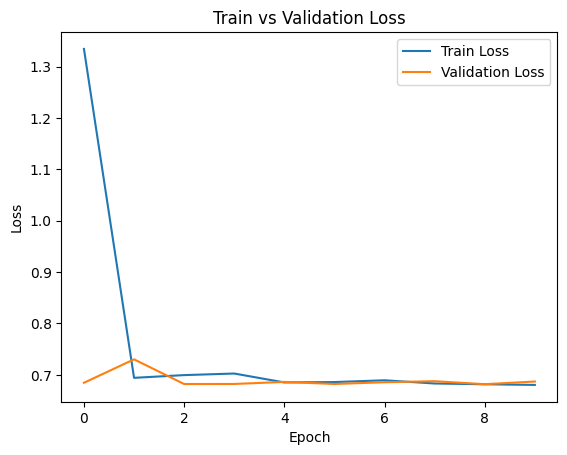

In [22]:
plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title("Train vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Accuracy Over Time

Visualize how training and validation accuracy improve over epochs:


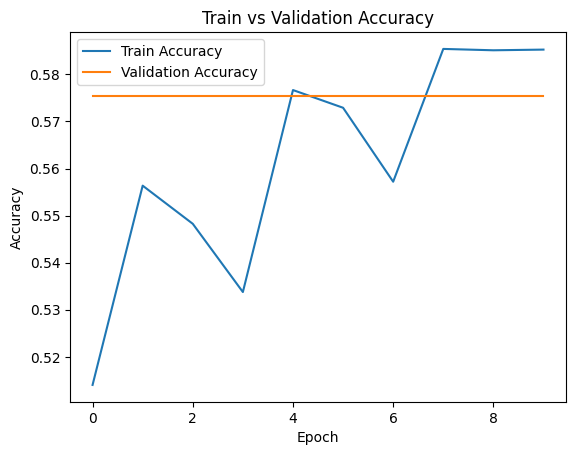

In [23]:
plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Test Function
This function evaluates the model on test data (final evaluation):

In [24]:
def test_step(model, dataloader, loss_fn, device):
    """Test step - final evaluation on test set"""
    model.eval()
    test_loss = 0
    test_acc = 0
    
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            
            test_loss += loss.item()
            y_pred_class = y_pred.argmax(dim=1)
            test_acc += (y_pred_class == y).sum().item() / len(y)
    
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    
    return test_loss, test_acc

# Final Evaluation on Test Set

After training is complete, evaluate the model on the held-out test set:

In [25]:
test_loss, test_acc = test_step(
    model=vit,
    dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.6749
Final Test Accuracy: 0.5990
